# Credible intervals for mROI at elevated spend

**What this notebook closes.** `final/roi-vs-mroi-metric-selection.ipynb` §5
establishes the talk's sharpest number -- mROI at elevated spend, where the
default prior's concealed error surfaces -- but computes it from posterior
*mean* parameters. That yields one line per variant and no uncertainty, so the
section's framing sentence, *"the model isn't just uncertain, it's confidently
wrong,"* is asserted rather than demonstrated. Confidently wrong is a claim
about **intervals**: it requires showing that the default's posterior at
elevated spend does not cover the truth.

**How.** Through Meridian's own `Analyzer.marginal_roi(new_data=...)`, which
returns the full posterior rather than a point estimate. This matters for a
talk that critiques Meridian's defaults: every number here comes from the
library's own analysis API, so "you hand-rolled the math" is not available as
an objection. §2 shows the API reproduces §5's hand-rolled curve to within
0.5%, which retro-validates the original section rather than replacing it.

**Why `marginal_roi(new_data=<scaled>)` gives mROI at elevated spend.**
Reading `analyzer.py`, `marginal_roi` is

```
incremental_outcome(scaling_factor0=1, scaling_factor1=1 + incremental_increase)
    / (total_spend * incremental_increase)
```

so it always perturbs *around whatever base it is given*. Passing `new_data`
with every paid input **and its spend** scaled by `m` moves that base to `m`x:
the numerator becomes the outcome change from `m` to `m(1 + delta)`, and the
denominator becomes `m * spend * delta`. That is exactly mROI at `m`x spend, and
no part of it is computed outside Meridian.

**No refitting.** The four fits from the metric-selection run are already saved
as `.nc` inference data. `Meridian(..., inference_data=...)` accepts them
directly (and validates their coordinates against the model), so this notebook
reconstructs the fitted models in seconds instead of re-running ~9 minutes of
MCMC. §2 asserts the reattached posterior reproduces the saved comparison table
before anything is computed from it.

**Merging.** This is written to be folded into the metric-selection notebook as
a replacement for §5 -- see the final section for the specific instructions. It
is kept separate for now so §5's existing numbers stay citable while the talk is
being built.

In [1]:
import os
import sys
import time

# Resolve the study directory (holding data_simulator.py / model_utils.py)
# whether this runs from `final/` or from `demo/synthetic/`.
STUDY_DIR = next(
    d for d in (os.path.abspath(os.getcwd()),
                os.path.abspath(os.path.join(os.getcwd(), '..')))
    if os.path.exists(os.path.join(d, 'data_simulator.py')))
if STUDY_DIR not in sys.path:
  sys.path.insert(0, STUDY_DIR)

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from meridian.analysis import analyzer
from meridian.analysis import tensors as m_tensors
from meridian.model import adstock_hill
from meridian.model import model

from data_simulator import SimulationConfig
from model_utils import build_model_spec
from model_utils import build_real_augmented_input

OUT_DIR = os.path.join(STUDY_DIR, 'fitted_models', 'mroi_metric_selection')
VARIANTS = ['default', 'ec_alpha_only']
MULTIPLIERS = [1, 2, 3, 5, 10]
SIM_SEED = 0
HDI_PROB = 0.9
SCENARIO = 'ec9'          # the metric-selection notebook's primary scenario
TARGET_EC_M_TV = 9.0

print('study dir:', STUDY_DIR)
print('artifacts:', OUT_DIR)

study dir: /Users/mariappan.subramanian/Documents/repo/meridian/demo/synthetic
artifacts: /Users/mariappan.subramanian/Documents/repo/meridian/demo/synthetic/fitted_models/mroi_metric_selection


## 1. Rebuild the scenario

Identical to the metric-selection notebook's §1: the Display-fixed scenario with
TV's `adstock_retention_range` pinned to `(0.8, 0.8)`, and TV's true `ec_m`
solved for by choosing the `saturation_frequency` that lands it at 9.0 (inside
the default prior's `[0.1, 10]` support). The simulator is seeded, so this
reproduces the exact dataset the saved fits were trained on -- §2 verifies that
rather than trusting it.

The real demo data is read from Meridian's repository, matching the source
notebook. Swap in the local copy at
`meridian/data/simulated_data/csv/geo_media_rf.csv` if running offline.

In [2]:
BASE_OVERRIDES = {
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.50, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {'TV': (1, 2), 'Display': (1, 5), 'Social': (7.0, 8.0)},
    'target_roi': {'TV': 8.0, 'Display': 5.0, 'Social': 3.0},
    'max_lag': 13,
    'n_times': 156,
    'n_knots_mu_t': 8,
    'roi_ec_elasticity': -0.3,
    'roi_alpha_elasticity': 0.3,
    'adstock_retention_range': {
        'TV': (0.8, 0.8), 'Display': (0.0, 0.3), 'Social': (0.1, 0.4),
    },
}

real_df = pd.read_csv(
    'https://raw.githubusercontent.com/google/meridian/refs/heads/main/meridian/data/simulated_data/csv/geo_media_rf.csv'
)


def build(saturation_frequency_tv=None):
  overrides = dict(BASE_OVERRIDES)
  if saturation_frequency_tv is not None:
    overrides['saturation_frequency'] = {
        'TV': saturation_frequency_tv, 'Display': 4.0, 'Social': 4.0}
  np.random.seed(SIM_SEED)
  tf.random.set_seed(SIM_SEED)
  cfg = SimulationConfig.from_dict(overrides)
  sim, data, gt = build_real_augmented_input(
      cfg, real_df,
      rf_source_map={'TV': 'Channel3'},
      plain_source_map={'Display': 'Channel2', 'Social': 'Channel1'},
  )
  return cfg, sim, data, gt


# ec_m is linear in saturation_frequency, so one baseline run calibrates it.
_, sim_base, _, _ = build()
sf_tv = 4.0 * TARGET_EC_M_TV / float(sim_base.ec_m.numpy()[0])
config, sim, input_data, ground_truth = build(sf_tv)

channels = list(config.channel_names)
I_TV = channels.index('TV')
true_ec = sim.ec_m.numpy()
true_alpha = sim.alpha_m.numpy()
true_roi = np.asarray(ground_truth['roi_m'])

assert abs(float(true_ec[I_TV]) - TARGET_EC_M_TV) < 0.05, 'ec_m solve missed'
print(f'channels: {channels}')
print(f'true ec_m:  {np.round(true_ec, 3)}')
print(f'true roi_m: {np.round(true_roi, 3)}')

I0000 00:00:1785296543.654518  521259 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [11.069365    1.3505481   0.29689494]
ec_m = [9.000001   1.3505481  0.29689494]


channels: ['TV', 'Display', 'Social']
true ec_m:  [9.    1.351 0.297]
true roi_m: [6.66  3.664 4.918]


## 2. Reattach the saved posteriors, and verify them

`Meridian.__init__` accepts an `inference_data` argument and validates its geo /
time / channel coordinates against the model it is being attached to, so a saved
posterior can be reattached without refitting and without `joblib`. That matters
here for the same reason the source notebook refuses to `load_mmm`: pickles are
only loadable by the build that wrote them, whereas NetCDF is portable.

**Two assertions before any result is computed from these models**, because a
silently mismatched dataset would produce plausible-looking but meaningless
intervals:

1. the reattached posterior mean for `ec_m` matches the saved comparison table;
2. `marginal_roi()` at 1x reproduces the saved `ec9_current_spend.csv`.

If the rebuilt scenario differed from the one the fits were trained on, (2)
would fail -- it exercises the full path from `input_data` through the posterior.

In [3]:
saved_current = pd.read_csv(os.path.join(OUT_DIR, f'{SCENARIO}_current_spend.csv'))

fitted, analyzers = {}, {}
for variant in VARIANTS:
  idata = az.from_netcdf(
      os.path.join(OUT_DIR, f'{SCENARIO}_{variant}_inference_data.nc'))
  spec = build_model_spec(variant, sim, config, media_prior_type='roi')
  fitted[variant] = model.Meridian(
      input_data=input_data, model_spec=spec, inference_data=idata)
  analyzers[variant] = analyzer.Analyzer(fitted[variant])

rows = []
for variant in VARIANTS:
  post_ec = float(
      fitted[variant].inference_data.posterior['ec_m'].values[..., I_TV].mean())
  mroi_1x = float(analyzers[variant].marginal_roi().numpy()[..., I_TV].mean())
  ref = float(saved_current.query(
      'variant == @variant and channel == "TV"')['mroi'].iloc[0])
  rows.append({'variant': variant,
               'posterior_ec_m[TV]': round(post_ec, 3),
               'mroi_1x_recomputed': round(mroi_1x, 4),
               'mroi_1x_saved': round(ref, 4),
               'abs_diff': round(abs(mroi_1x - ref), 5)})
  assert abs(mroi_1x - ref) < 0.02, (
      f'{variant}: reattached model does not reproduce the saved 1x mROI '
      f'({mroi_1x:.4f} vs {ref:.4f}) -- the rebuilt scenario likely differs '
      'from the one these fits were trained on.')

print('reattachment verified: rebuilt scenario reproduces the saved fits\n')
pd.DataFrame(rows)

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_51089/1175813818.py:10: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  analyzers[variant] = analyzer.Analyzer(fitted[variant])
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_51089/1175813818.py:10: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  analyzers[variant] = analyzer.Analyzer(fitted[variant])


reattachment verified: rebuilt scenario reproduces the saved fits



,variant,posterior_ec_m[TV],mroi_1x_recomputed,mroi_1x_saved,abs_diff
0,default,2.842,5.5500,5.550,0.00005
1,ec_alpha_only,9.143,5.8575,5.857,0.00049


## 3. mROI across the spend sweep, with posterior intervals

`scaled_inputs` scales every paid input **and its spend** by the multiplier.
Scaling both is what keeps the quantity interpretable as *mROI at `m`x spend*
rather than *mROI at `m`x media on unchanged spend*.

Two deliberate choices:

- **`frequency` and `revenue_per_kpi` are not scaled.** Where a channel carries
  reach/frequency, scaling `reach` alone raises impressions by `m` at constant
  frequency, matching how the source notebook's DGP truth scales per-capita
  impressions. (In this particular build all three channels are plain media
  channels, so this branch is inert -- but leaving it in keeps the helper correct
  if the scenario is rebuilt with an R&F channel.)
- **The full posterior is kept**, not summarized inside the loop, so the interval
  is computed from draws rather than from a normal approximation.

In [4]:
def scaled_inputs(mmm, mult):
  '''DataTensors with every paid input and its spend scaled by `mult`.'''
  d = mmm.input_data
  kw = {}
  for name in ('media', 'media_spend', 'reach', 'rf_spend'):
    v = getattr(d, name, None)
    if v is not None:
      kw[name] = tf.constant(v.values * mult, dtype=tf.float32)
  for name in ('frequency', 'revenue_per_kpi'):
    v = getattr(d, name, None)
    if v is not None:
      kw[name] = tf.constant(v.values, dtype=tf.float32)
  return m_tensors.DataTensors(**kw)


t0 = time.time()
draws = {}   # (variant, mult) -> posterior draws of TV mROI
for variant in VARIANTS:
  for mult in MULTIPLIERS:
    d = analyzers[variant].marginal_roi(
        new_data=scaled_inputs(fitted[variant], mult)).numpy()[..., I_TV]
    draws[(variant, mult)] = d.reshape(-1)
print(f'{len(draws)} posterior mROI distributions in {time.time() - t0:.0f}s; '
      f'{draws[(VARIANTS[0], 1)].size} draws each')

10 posterior mROI distributions in 1s; 2000 draws each


## 4. The DGP truth on the same sweep

The truth has no posterior -- it is a property of the data-generating process --
so it is computed directly from the true parameters, through Meridian's own
`AdstockTransformer` / `HillTransformer` rather than a closed form.

For a channel whose spend scales linearly with its media, mROI at `m`x is

```
mROI(m) = true_roi * [inc(m * 1.01) - inc(m)] / (0.01 * m * inc(1))
```

where `inc(z)` is mean incremental outcome at `z`x delivery. Dividing by
`inc(1)` and multiplying by `true_roi` converts outcome units into ROI units
using the exactly-known true ROI, which is why no anchoring constant is needed.
This is algebraically identical to the anchored construction in the source
notebook's §5 -- it just makes the calibration explicit instead of implicit.

In [5]:
x_scaled = sim.transformed_ipc_gtm.numpy()
beta_gm = sim.beta_gm.numpy()


def incremental(mult, ch_idx):
  '''Mean incremental outcome for one channel at `mult`x delivery.'''
  m = tf.constant(x_scaled[:, :, ch_idx:ch_idx + 1] * mult, dtype=tf.float32)
  adstocked = adstock_hill.AdstockTransformer(
      alpha=tf.constant([float(true_alpha[ch_idx])], tf.float32),
      max_lag=config.max_lag, n_times_output=config.n_times).forward(m)
  hilled = adstock_hill.HillTransformer(
      ec=tf.constant([float(true_ec[ch_idx])], tf.float32),
      slope=tf.constant([1.0], tf.float32)).forward(adstocked).numpy()[:, :, 0]
  return float((hilled * beta_gm[:, ch_idx][:, None]).mean())


inc_1x = incremental(1.0, I_TV)
true_mroi = {
    m: float(true_roi[I_TV]) * (incremental(m * 1.01, I_TV) - incremental(m, I_TV))
       / (0.01 * m * inc_1x)
    for m in MULTIPLIERS
}
print('true TV mROI by spend multiple:')
for m in MULTIPLIERS:
  print(f'  {m:2d}x  {true_mroi[m]:.3f}')

true TV mROI by spend multiple:
   1x  5.977
   2x  4.933
   3x  4.150
   5x  3.066
  10x  1.698


## 5. The result: does each posterior cover the truth?

This is the table the talk's framing sentence depends on. `covers_truth` is the
whole question -- a `default` interval that **excludes** the truth is the
difference between "the model is uncertain" and "the model is confidently
wrong," and only the latter supports the argument being made.

In [6]:
rows = []
for variant in VARIANTS:
  for m in MULTIPLIERS:
    d = draws[(variant, m)]
    lo, hi = az.hdi(d, hdi_prob=HDI_PROB)
    t = true_mroi[m]
    rows.append({
        'variant': variant, 'spend': f'{m}x',
        'true_mroi': round(t, 3),
        'post_mean': round(float(d.mean()), 3),
        'err_pct': round(float(d.mean() / t - 1) * 100, 1),
        f'hdi_{int(HDI_PROB * 100)}_lo': round(float(lo), 3),
        f'hdi_{int(HDI_PROB * 100)}_hi': round(float(hi), 3),
        'covers_truth': bool(lo <= t <= hi),
        'gap_to_truth': 0.0 if lo <= t <= hi else round(
            float(t - hi if t > hi else lo - t), 3),
    })
intervals = pd.DataFrame(rows)
intervals.to_csv(
    os.path.join(OUT_DIR, f'{SCENARIO}_mroi_sweep_intervals.csv'), index=False)

d_cov = intervals.query('variant == "default"')['covers_truth']
i_cov = intervals.query('variant == "ec_alpha_only"')['covers_truth']
print(f'default:       covers truth at {d_cov.sum()}/{len(d_cov)} spend levels')
print(f'ec_alpha_only: covers truth at {i_cov.sum()}/{len(i_cov)} spend levels')
intervals

default:       covers truth at 1/5 spend levels
ec_alpha_only: covers truth at 5/5 spend levels


,variant,spend,true_mroi,post_mean,err_pct,hdi_90_lo,hdi_90_hi,covers_truth,gap_to_truth
0,default,1x,5.977,5.550,-7.1,4.969,6.137,True,0.000
1,default,2x,4.933,3.514,-28.8,3.026,4.049,False,0.885
2,default,3x,4.150,2.442,-41.2,2.002,2.914,False,1.236
3,default,5x,3.066,1.388,-54.7,1.041,1.710,False,1.356
4,default,10x,1.698,0.540,-68.2,0.383,0.715,False,0.983
5,ec_alpha_only,1x,5.977,5.857,-2.0,5.277,6.407,True,0.000
6,ec_alpha_only,2x,4.933,4.838,-1.9,4.345,5.320,True,0.000
7,ec_alpha_only,3x,4.150,4.073,-1.9,3.640,4.530,True,0.000
8,ec_alpha_only,5x,3.066,3.015,-1.7,2.618,3.397,True,0.000
9,ec_alpha_only,10x,1.698,1.676,-1.3,1.401,1.965,True,0.000


## 6. The slide

Bands are `HDI_PROB` posterior intervals. The claim to read off it: past 1x the
default's band separates from the truth and stays separated, while the informed
prior's band tracks it. Separation -- not the gap between two means -- is what
"confidently wrong" means.

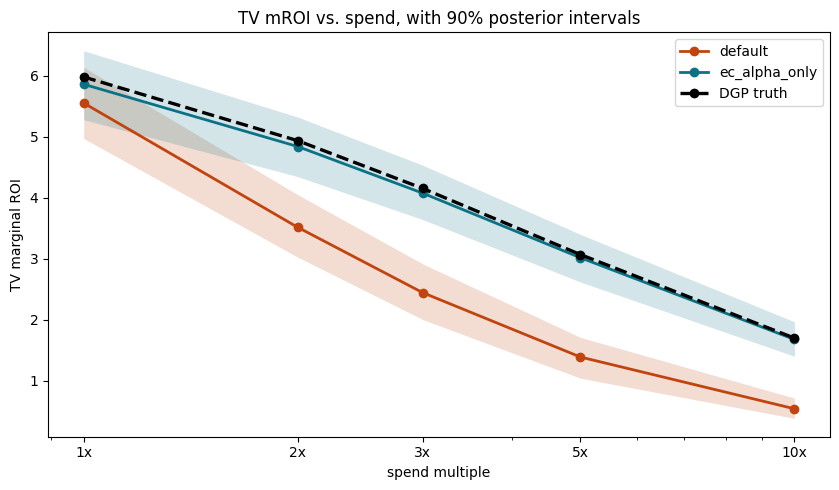

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5))
style = {'default': '#c1440e', 'ec_alpha_only': '#0b7285'}
for variant in VARIANTS:
  mean = [draws[(variant, m)].mean() for m in MULTIPLIERS]
  lo = [az.hdi(draws[(variant, m)], hdi_prob=HDI_PROB)[0] for m in MULTIPLIERS]
  hi = [az.hdi(draws[(variant, m)], hdi_prob=HDI_PROB)[1] for m in MULTIPLIERS]
  ax.plot(MULTIPLIERS, mean, 'o-', color=style[variant], lw=2, label=variant, zorder=3)
  ax.fill_between(MULTIPLIERS, lo, hi, color=style[variant], alpha=0.18, lw=0)
ax.plot(MULTIPLIERS, [true_mroi[m] for m in MULTIPLIERS], 'ko--', lw=2.4,
        label='DGP truth', zorder=4)
ax.set_xscale('log')
ax.set_xticks(MULTIPLIERS)
ax.set_xticklabels([f'{m}x' for m in MULTIPLIERS])
ax.set_xlabel('spend multiple')
ax.set_ylabel('TV marginal ROI')
ax.set_title(f'TV mROI vs. spend, with {int(HDI_PROB * 100)}% posterior intervals')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{SCENARIO}_mroi_intervals.png'), dpi=150)
plt.show()

## 7. Merging this into the metric-selection notebook

Written to drop in as a replacement for §5 of
`final/roi-vs-mroi-metric-selection.ipynb`:

1. **Replace §5's `mroi_curve` / `curves` / `mroi_table` cell** with §3 + §5 here.
   The source notebook's `incremental()` helper stays -- §4 here still uses it for
   the DGP truth, which has no posterior to draw from.
2. **Drop §5's anchoring step.** `anchor_mroi` and the `scale = anchor / raw[0]`
   line exist only because the hand-rolled curve had no absolute calibration.
   `marginal_roi` returns calibrated mROI directly.
3. **Delete §5's caveat paragraph** ("these are posterior-*mean* point
   estimates...") and **caveat 2 in §7**, along with the corresponding open item
   in `ARF_COUNCIL_TALK_OUTLINE.md`.
4. **Update §7's ranking table** to quote the interval rather than the point
   error for rank 1.
5. Keep §2's reattachment assertions if the merged notebook still loads saved
   fits; drop them if it refits inline, since the mismatch they guard against
   cannot arise then.

Merging does **not** change any conclusion in the source notebook -- §2 shows the
point estimates agree. It changes what can be *claimed* about them.